# Benchmarking `nvjpeg` 📊

In [7]:
#%run benchmark_libjpeg-turbo_LoLa.py

# 📈 Data Visualization & Analysis

Now we will plot the collected data to understand the results. We will focus on:
1.  **Rate-Distortion:** How do quality metrics (like VMAF) change with file size?
2.  **Quality vs. File Size:** How does the `-quality` setting impact file size for different subsampling methods?
3.  **Encoding Performance:** Which DCT method is fastest? How does resolution affect encoding time?
4.  **Decoding Performance:** How does resolution affect decoding time?

In [8]:
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv("C:/Users/s248508/Pictures/benchmark-result/nvjpeg_results_LoLa_1280x720.csv")
df.head()

,img_name,subsampling,quality,enc_avg_time_milliseconds,enc_avg_fps,enc_avg_mps,dec_avg_time_milliseconds,dec_avg_fps,dec_avg_mps,compressed_size_bytes,compression_ratio,bpp,psnr,ssim
0,r000da54ft.rgb,420,40,0.66,1515.152,1396.363636,1.84,543.478,500.869565,79001,34.997025,0.685773,34.4097,0.952991
1,r000da54ft.rgb,420,41,0.71,1408.451,1298.028169,1.90,526.316,485.052632,80665,34.275088,0.700217,34.5504,0.954361
2,r000da54ft.rgb,420,42,0.68,1470.588,1355.294118,1.83,546.448,503.606557,81685,33.847096,0.709071,34.6081,0.955102
3,r000da54ft.rgb,420,43,0.67,1492.537,1375.522388,1.89,529.101,487.619048,82434,33.539559,0.715573,34.6781,0.955554
4,r000da54ft.rgb,420,44,1.17,854.701,787.692308,2.03,492.611,453.990148,83912,32.948804,0.728403,34.8412,0.956854


In [10]:
plt.style.use('default')

## Encoding Parameters vs. quality metrics

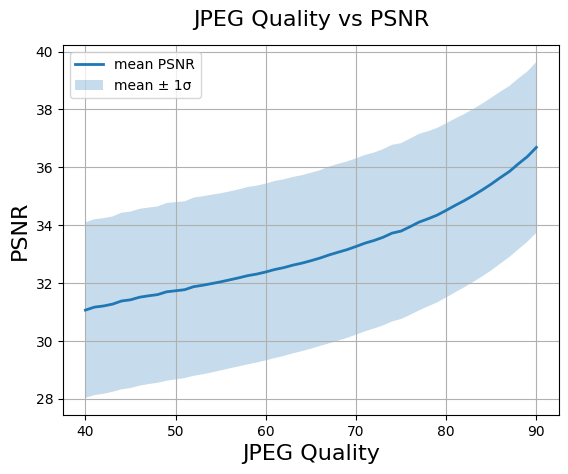

In [11]:
# Aggregate per quality across experiments
stats = (
    df.groupby("quality", as_index=False)["psnr"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

x = stats["quality"].to_numpy()
m = stats["mean"].to_numpy()
s = stats["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s = np.nan_to_num(s, nan=0.0)

fig, ax = plt.subplots()
ax.set_title("JPEG Quality vs PSNR", y=1.03, fontsize=16)
ax.set_xlabel("JPEG Quality", fontsize=16)
ax.set_ylabel("PSNR", fontsize=16)
ax.grid(True)

ax.plot(x, m, label="mean PSNR", linewidth=2)
ax.fill_between(x, m - s, m + s, alpha=0.25, label="mean ± 1σ")

ax.legend()
plt.show()

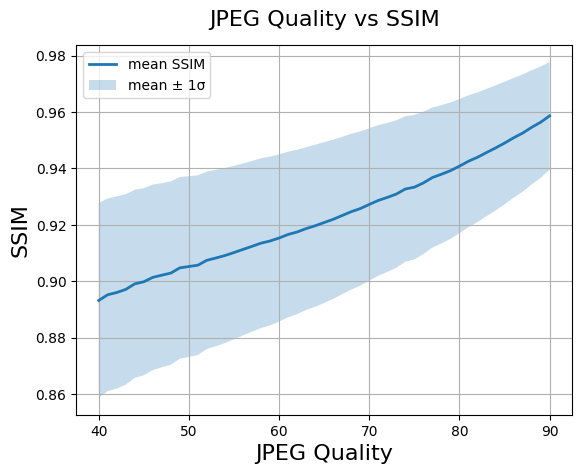

In [12]:
# Aggregate per quality across experiments
stats = (
    df.groupby("quality", as_index=False)["ssim"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

x = stats["quality"].to_numpy()
m = stats["mean"].to_numpy()
s = stats["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s = np.nan_to_num(s, nan=0.0)

fig, ax = plt.subplots()
ax.set_title("JPEG Quality vs SSIM", y=1.03, fontsize=16)
ax.set_xlabel("JPEG Quality", fontsize=16)
ax.set_ylabel("SSIM", fontsize=16)
ax.grid(True)

ax.plot(x, m, label="mean SSIM", linewidth=2)
ax.fill_between(x, m - s, m + s, alpha=0.25, label="mean ± 1σ")

ax.legend()
plt.show()

## Encoding Parameters vs. File Size


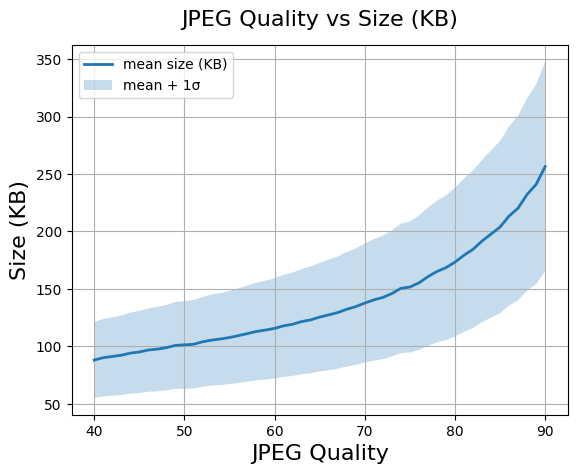

In [13]:
# Aggregate per quality across experiments
stats = (
    df.groupby("quality", as_index=False)["compressed_size_bytes"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

x = stats["quality"].to_numpy()
m = stats["mean"].to_numpy()/1000
s = stats["std"].to_numpy()/1000

# Handle edge case: std is NaN when only 1 sample exists at a quality
s = np.nan_to_num(s, nan=0.0)

fig, ax = plt.subplots()
ax.set_title("JPEG Quality vs Size (KB)", y=1.03, fontsize=16)
ax.set_xlabel("JPEG Quality", fontsize=16)
ax.set_ylabel("Size (KB)", fontsize=16)
ax.grid(True)

ax.plot(x, m, label="mean size (KB)", linewidth=2)
ax.fill_between(x, m - s, m + s, alpha=0.25, label="mean + 1σ")

ax.legend()
plt.show()

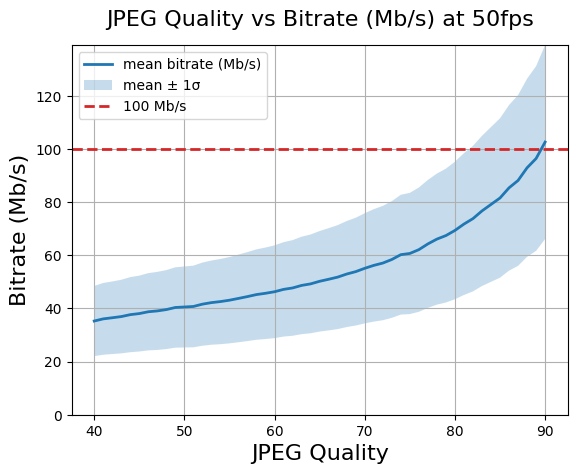

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Aggregate per quality across experiments
stats = (
    df.groupby("quality", as_index=False)["compressed_size_bytes"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

x = stats["quality"].to_numpy()
m = stats["mean"].to_numpy() * 50 * 8 / 1_000_000   # Mb/s @ 50 fps
s = stats["std"].to_numpy()  * 50 * 8 / 1_000_000

s = np.nan_to_num(s, nan=0.0)

fig, ax = plt.subplots()
ax.set_title("JPEG Quality vs Bitrate (Mb/s) at 50fps", y=1.03, fontsize=16)
ax.set_xlabel("JPEG Quality", fontsize=16)
ax.set_ylabel("Bitrate (Mb/s)", fontsize=16)
ax.grid(True)

ax.plot(x, m, label="mean bitrate (Mb/s)", linewidth=2)
ax.fill_between(x, m - s, m + s, alpha=0.25, label="mean ± 1σ")

# --- Household connection reference lines ---
ax.axhline(100, color="tab:red",   linestyle="--", linewidth=2, label="100 Mb/s")

# Optional: ensure lines are visible even if data range is outside
ax.set_ylim(bottom=0, top=max(np.max(m + s), 110))

ax.legend()
plt.show()

## Encoding Parameters vs. Performance

As we expected, encoding and decoding in 4:2:0 is the fastest, so we will perform our remaining analysis fixed on this subsampling setting.

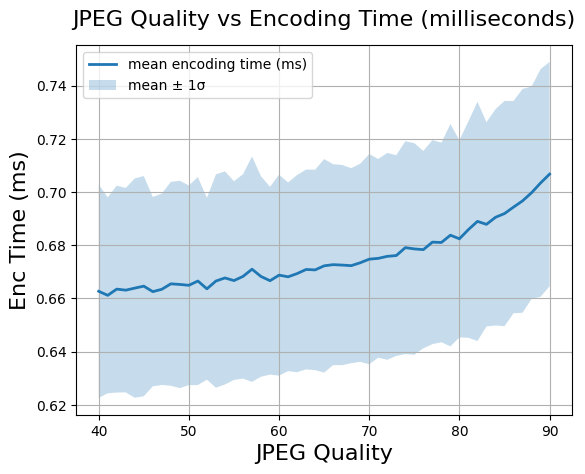

In [15]:
# Aggregate per quality across experiments
stats = (
    df.groupby("quality", as_index=False)["enc_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

x = stats["quality"].to_numpy()
m = stats["mean"].to_numpy()
s = stats["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s = np.nan_to_num(s, nan=0.0)

fig, ax = plt.subplots()
ax.set_title("JPEG Quality vs Encoding Time (milliseconds)", y=1.03, fontsize=16)
ax.set_xlabel("JPEG Quality", fontsize=16)
ax.set_ylabel("Enc Time (ms)", fontsize=16)
ax.grid(True)

ax.plot(x, m, label="mean encoding time (ms)", linewidth=2)
ax.fill_between(x, m - s, m + s, alpha=0.25, label="mean ± 1σ")

ax.legend()
plt.show()

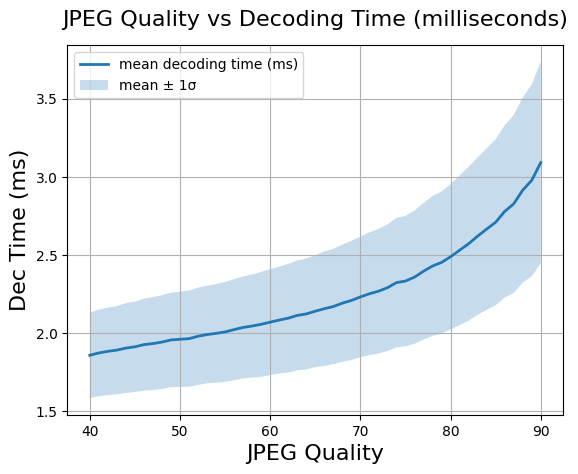

In [16]:
# Aggregate per quality across experiments
stats = (
    df.groupby("quality", as_index=False)["dec_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

x = stats["quality"].to_numpy()
m = stats["mean"].to_numpy()
s = stats["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s = np.nan_to_num(s, nan=0.0)

fig, ax = plt.subplots()
ax.set_title("JPEG Quality vs Decoding Time (milliseconds)", y=1.03, fontsize=16)
ax.set_xlabel("JPEG Quality", fontsize=16)
ax.set_ylabel("Dec Time (ms)", fontsize=16)
ax.grid(True)

ax.plot(x, m, label="mean decoding time (ms)", linewidth=2)
ax.fill_between(x, m - s, m + s, alpha=0.25, label="mean ± 1σ")

ax.legend()
plt.show()

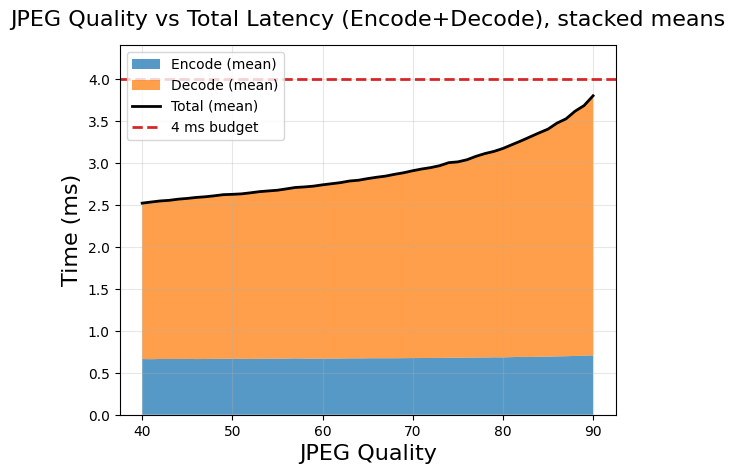

In [17]:
# Aggregate both metrics per quality (means + stds, in case you want them later)
stats = (
    df.groupby("quality", as_index=False)
      .agg(enc_mean=("enc_avg_time_milliseconds", "mean"),
           enc_std =("enc_avg_time_milliseconds", "std"),
           dec_mean=("dec_avg_time_milliseconds", "mean"),
           dec_std =("dec_avg_time_milliseconds", "std"))
      .sort_values("quality")
)

q   = stats["quality"].to_numpy()
enc = stats["enc_mean"].to_numpy()
dec = stats["dec_mean"].to_numpy()

total = enc + dec

fig, ax = plt.subplots()
ax.set_title("JPEG Quality vs Total Latency (Encode+Decode), stacked means", y=1.03, fontsize=16)
ax.set_xlabel("JPEG Quality", fontsize=16)
ax.set_ylabel("Time (ms)", fontsize=16)
ax.grid(True, alpha=0.3)

# Stacked mean areas
ax.stackplot(q, enc, dec, labels=["Encode (mean)", "Decode (mean)"], alpha=0.75)

# Total mean line (optional but usually useful)
ax.plot(q, total, color="black", linewidth=2, label="Total (mean)")

# 4 ms total latency budget
ax.axhline(4.0, color="tab:red", linestyle="--", linewidth=2, label="4 ms budget")

# Make sure budget line is visible
ax.set_ylim(bottom=0, top=max(total.max(), 4.0) * 1.1)

ax.legend(loc="upper left")
plt.show()